**Nombre:** Manuel Ramírez Galván

**Fecha:** 19/03/2025

**Actividad:** 2

In [2]:
!wget https://raw.githubusercontent.com/maticvl/dataHacker/master/DATA/Frame1.jpg -O "Frame1.jpg"
!wget https://raw.githubusercontent.com/maticvl/dataHacker/master/DATA/Frame2.jpg -O "Frame2.jpg"

--2025-03-20 04:13:14--  https://raw.githubusercontent.com/maticvl/dataHacker/master/DATA/Frame1.jpg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 75216 (73K) [image/jpeg]
Saving to: ‘Frame1.jpg’

Frame1.jpg          100%[===================>]  73.45K  --.-KB/s    in 0.002s  

2025-03-20 04:13:14 (31.8 MB/s) - ‘Frame1.jpg’ saved [75216/75216]

--2025-03-20 04:13:14--  https://raw.githubusercontent.com/maticvl/dataHacker/master/DATA/Frame2.jpg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 74275 (73K) [image/jpeg]
Saving to: ‘Fr

# <font color=blue> Movimiento y flujo óptico</font>


**Objetivos:**
Implementar técnicas de flujo óptico y detección de movimiento para identificar el desplazamiento de objetos.

## <font color=green> Ejercicio 1:  Importar bibliotecas necesarias</font>

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

## <font color=green> Ejercicio 2: Detección de Movimiento con Diferencias de Cuadros</font>

**Objetivo:** Detectar objetos en movimiento mediante diferencias de cuadros consecutivos.

**Pasos:**
1.   Corre el codigo para acceder a imagenes de github que se encuentra arriba de este notebook.
2.   Cargar las imagenes Frame1.jpg y Frame2.jpg con `cv2.imread()`.
2.   Convierte las imágenes a escala de grises con `cv2.cvtColor()`.
3.   Calcular la diferencia absoluta entre las imágenes con `cv2.absdiff()`.
4.   Aplicar un umbral binario para obtener una máscara de movimiento con `cv2.threshold()`.
5.   Mostrar el resultado con `plt.imshow()`.

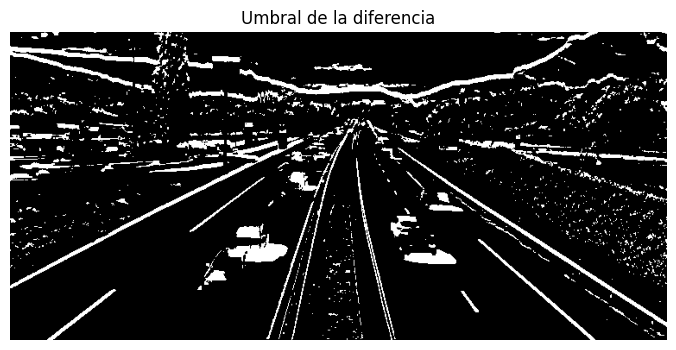

In [3]:
img1_path = cv2.imread('Frame1.jpg')
img2_path = cv2.imread('Frame2.jpg')

img1 = cv2.cvtColor(img1_path, cv2.COLOR_BGR2GRAY)
img2 = cv2.cvtColor(img2_path, cv2.COLOR_BGR2GRAY)

img1 = cv2.resize(img1, (img2.shape[1], img2.shape[0]))

diff = cv2.subtract(img2, img1)

_, thresh = cv2.threshold(diff, 30, 255, cv2.THRESH_BINARY)

plt.figure(figsize=(12, 4))
plt.imshow(thresh, cmap="gray")
plt.title("Umbral de la diferencia")
plt.axis("off")
plt.show()

## <font color=green> Ejercicio 3: Vectores de flujo óptico </font>

**Objetivo:** Calcular y visualizar el flujo óptico denso (movimiento de todos los píxeles) entre dos imágenes en escala de grises usando el método de Farneback.

**Pasos:**
1.   Calcular el flujo óptico de las dos imagenes reutiliza lo del ejercicio 2, utiliza el metodo `cv2.calcOpticalFlowFarneback()`
2.   Obtener la magnitud y el ángulo del flujo, con `cv2.cartToPolar()`.
3.   Crear una imagen vacía utilizando el modelo HSV para representar la dirección y magnitud del flujo utiliza `np.zeros()`.
4.   Realiza la configuracion de tono (convertir a grados), saturacion y valor. Recuerda normalizar la magnitud del flujo para ajustarla al rango 0-255.
5.   Visualizar la imagen con `plt.imshow()`.

67.65551 6.9107405e-06
6.2831383 0.00015145591
255 0


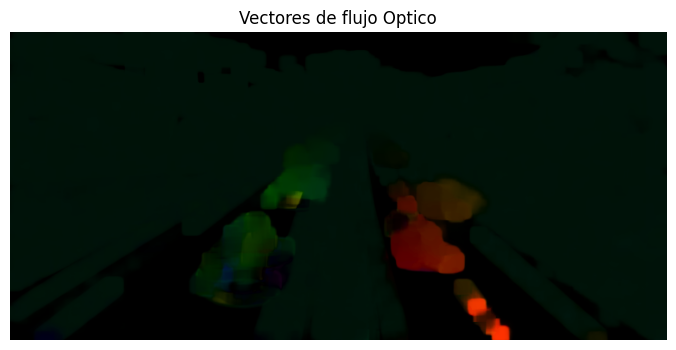

In [4]:
fl_op = cv2.calcOpticalFlowFarneback(img1, img2, None, 0.5, 5, 15,  3,  5,  1.2, 0)
mag, ang = cv2.cartToPolar(fl_op[..., 0], fl_op[..., 1])
hsv = np.zeros((img1.shape[0], img1.shape[1], 3), dtype=np.uint8)

hsv[..., 1] = 255
hsv[..., 0] = ang * 180 / np.pi / 2
hsv[..., 2] = cv2.normalize(mag, None, 0, 255, cv2.NORM_MINMAX)
flow_rgb = cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR)

print(mag.max(), mag.min())
print(ang.max(), ang.min())
print(hsv.max(), hsv.min())

plt.figure(figsize=(12, 4))
plt.imshow(flow_rgb)
plt.title("Vectores de flujo Optico")
plt.axis("off")
plt.show()

## <font color=green> Ejercicio 4:  Vectores de flujo óptico </font>

**Objetivo:** Representar el flujo óptico previamente calculado dibujando vectores sobre la imagen para indicar dirección y magnitud del movimiento en zonas específicas (muestreo).

**Pasos:**
1.   Crear una copia de la imagen 2 para dibujar los vectores de movimiento.
2.   Definir el paso (distancia entre vectores a dibujar), utilizando una variable.
3.   Obtener las dimensiones de la imagen (alto y ancho) utiliza `shape`.
4.   Recorrer la imagen tanto en alto como ancho (muestrea cada paso).
5.   Obtene los componentes de flujo en la posición `(x, y)`.
6.   Filtrar vectores con magnitud pequeña. utiliza `np.hypot()`.
7.   Define el punto final del vector y color.
8.   Dibujar una flecha desde el punto (x, y) al punto final. Utiliza `cv2.arrowedLine()`.
4.   Muestra el resultado con `plt.imshow()`.

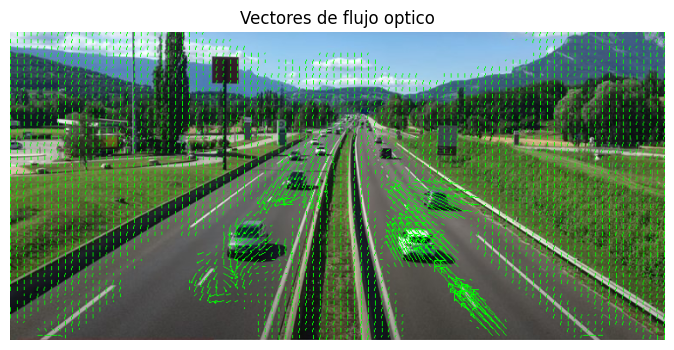

In [12]:
img1_c = img1_path.copy()

step = 8

height, width = diff.shape

for y in range(0, height, step):
    for x in range(0, width, step):
        fx, fy = fl_op[y, x]
        if np.hypot(fx, fy) > 1:
          end_point = (int(x + fx), int(y + fy))
          color = (0, 255, 0)
          cv2.arrowedLine(img1_c, (x, y), end_point, color, 1)

# Display the result
plt.figure(figsize=(12, 4))
plt.imshow(cv2.cvtColor(img1_c, cv2.COLOR_BGR2RGB))
plt.title("Vectores de flujo optico")
plt.axis("off")
plt.show()